# Customer Churn Analysis and Prediction for PowerCo

# Project Overview

PowerCo is a major gas and electricity utility provider serving small and medium-sized enterprises (SMEs) in a highly competitive energy market. The industry has undergone significant transformation due to new pricing structures, renewable energy adoption, and enhanced customer experiences offered by emerging providers.

As a result, PowerCo has experienced substantial customer losses, with churn rates exceeding 50%. This project aims to identify the key factors influencing customer churn and develop predictive models that can help the company proactively retain customers.


## Problem statement

Customer churn poses a major challenge to PowerCo's profitability and market share. Acquiring new customers is significantly more expensive than retaining existing ones. Therefore, understanding why customers leave and predicting future churn behavior is critical for business sustainability.

The objectives of this analysis are:

Identify factors influencing customer churn.
Explore customer consumption and pricing behavior.
Build a predictive model to identify customers at risk of churning.
Provide business recommendations to reduce churn and improve retention.

## Import Libraries

In [3]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing and Model Selection
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')


The required python libraries were imported to aid in data manipulation, visualisation,preprocessing, machine learning model development,hyperparameter tuning and model evaluation.The libraries provided tools necessary for data exploration,built machine learning models and evaluated the model performance to predict customer churn.

## Loading  Data 

In [4]:
client = pd.read_csv('client_data (1).csv')
price = pd.read_csv ('price_data (1).csv')

The customer and price dataset were imported to pandas dataframes using the read_csv() function.This prepared the data for data cleaning and exploratory analysis 

## Exploratory Data Analysis

### Data Structure

Client Dataset Overview

In [5]:
client.info()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  str    
 1   channel_sales                   14606 non-null  str    
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  str    
 6   date_end                        14606 non-null  str    
 7   date_modif_prod                 14606 non-null  str    
 8   date_renewal                    14606 non-null  str    
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         14606 non-n

In [6]:
client.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [7]:
client.shape

(14606, 26)

In [8]:
client.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


The client dataset has 14606 rows and 26 columns whose data types are integer  ,strings and  float .

An approximate 9.7% churn rate indicated  10% churn and 90% retain in chustomers suggesting a class imbalance.

Consumption related variables like annual consumption(cons12_m) and annual gas consumption(cons_gas_12m) indicated a high right skewed distribution due to the few customers having extremely high consumption and that more than half of consumers have no gas consumption indicating many electricity only ocnsumers respectively.

Price variables like forecasted price energy off peak and peak have low variation indicating price pattern stability among consumers.

Customers tenure averaging at 5 years indicated that most customers have stayed for years 

Product activity median at 1 indicate d taht most customers have only 1 active product with a smaller number having many products.

Some features like maximum power,forecasted consumption,net margin have outliers due to large gaps between mean and median which may influence the predictive performance.

Gross power and net power have strong correlation indicating multicollinearity which can be assed for model development.


Price Dataset Overview

In [9]:
# the data types and non-null values in the price dataset
price.info()

<class 'pandas.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  str    
 1   price_date          193002 non-null  str    
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), str(2)
memory usage: 19.5 MB


In [10]:
# Check the first 5 rows of the price dataset
price.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [11]:
# the number of rows and columns in the price dataset
price.shape

(193002, 8)

In [12]:
# the summary statistics of the price dataset
price.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


The price dataset has 193,002 rows and 8 columnsm with the data types namely strings or float 64.

The maximum  varying prices for off peak peak and mid peak per unit is 0.28 ,0.22 and 0.11 per unit KW/h and the maximum fixed price being 59 , 36 and 17 .

The variable pricing components off peak,mid peak and peak.
Off peak have a symmetric distribution indicating most customers pay similar off peak rates.
Peak has a skewed distribution due to the difference between mean and median.The zero value for 25th percentile indicates that some customers are not subjected to peak pricing.
Mid peak has 0 median observation indicating that mid peak pricing is not apllicable to large share of customers.

The fixed pricing components off peak,mid peak and peak.
Off peak has symmetrics inidcating a standardised price across customers.
Peak has zero value for median and a quarter of the customers have no fixed peak charge indicating thta peak pricing plans are not universally applied.
Mid peak is similar to peak interm of zero value for median and a quarter of customers indicatiing that many customers lack mid peak fixed chargs.


### Data Cleaning

1. Missing Values

In [13]:
# check for missing values in both datasets

client.isnull().sum()
price.isnull().sum()

print(client.isnull().sum())
print(price.isnull().sum())

id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
origin_up                         0
pow_max                           0
churn                             0
dtype: int64
id                    0
price_date            0
pri

In [14]:
price.isnull().sum()

id                    0
price_date            0
price_off_peak_var    0
price_peak_var        0
price_mid_peak_var    0
price_off_peak_fix    0
price_peak_fix        0
price_mid_peak_fix    0
dtype: int64

Both datasets have no missing values indicating complete data for all variables

2. Duplicated Values

In [15]:
# sum of duplicated rows in both datasets

client.duplicated().sum()
price.duplicated().sum() 

print(client.duplicated().sum())
print(price.duplicated().sum())

0
0


Both datasets had no duplicated values indicating unique data

3. Conversion of datatypes

In [16]:
# Convert date columns to datetime format

client['date_activ'] = pd.to_datetime(client['date_activ'])
client['date_end'] = pd.to_datetime(client['date_end'])

price['price_date'] = pd.to_datetime(price['price_date'])

The date columns in both datasets were converted to datetime format

4. Detecting Outliers

cons_12m: 2084 outliers
cons_gas_12m: 2612 outliers
cons_last_month: 2051 outliers
forecast_cons_12m: 1054 outliers
forecast_cons_year: 1298 outliers
forecast_discount_energy: 512 outliers
forecast_meter_rent_12m: 152 outliers
forecast_price_energy_off_peak: 371 outliers
forecast_price_pow_off_peak: 345 outliers
imp_cons: 1215 outliers
margin_gross_pow_ele: 660 outliers
margin_net_pow_ele: 660 outliers
nb_prod_act: 3175 outliers
net_margin: 1022 outliers
num_years_antig: 389 outliers
pow_max: 1535 outliers
churn: 1419 outliers


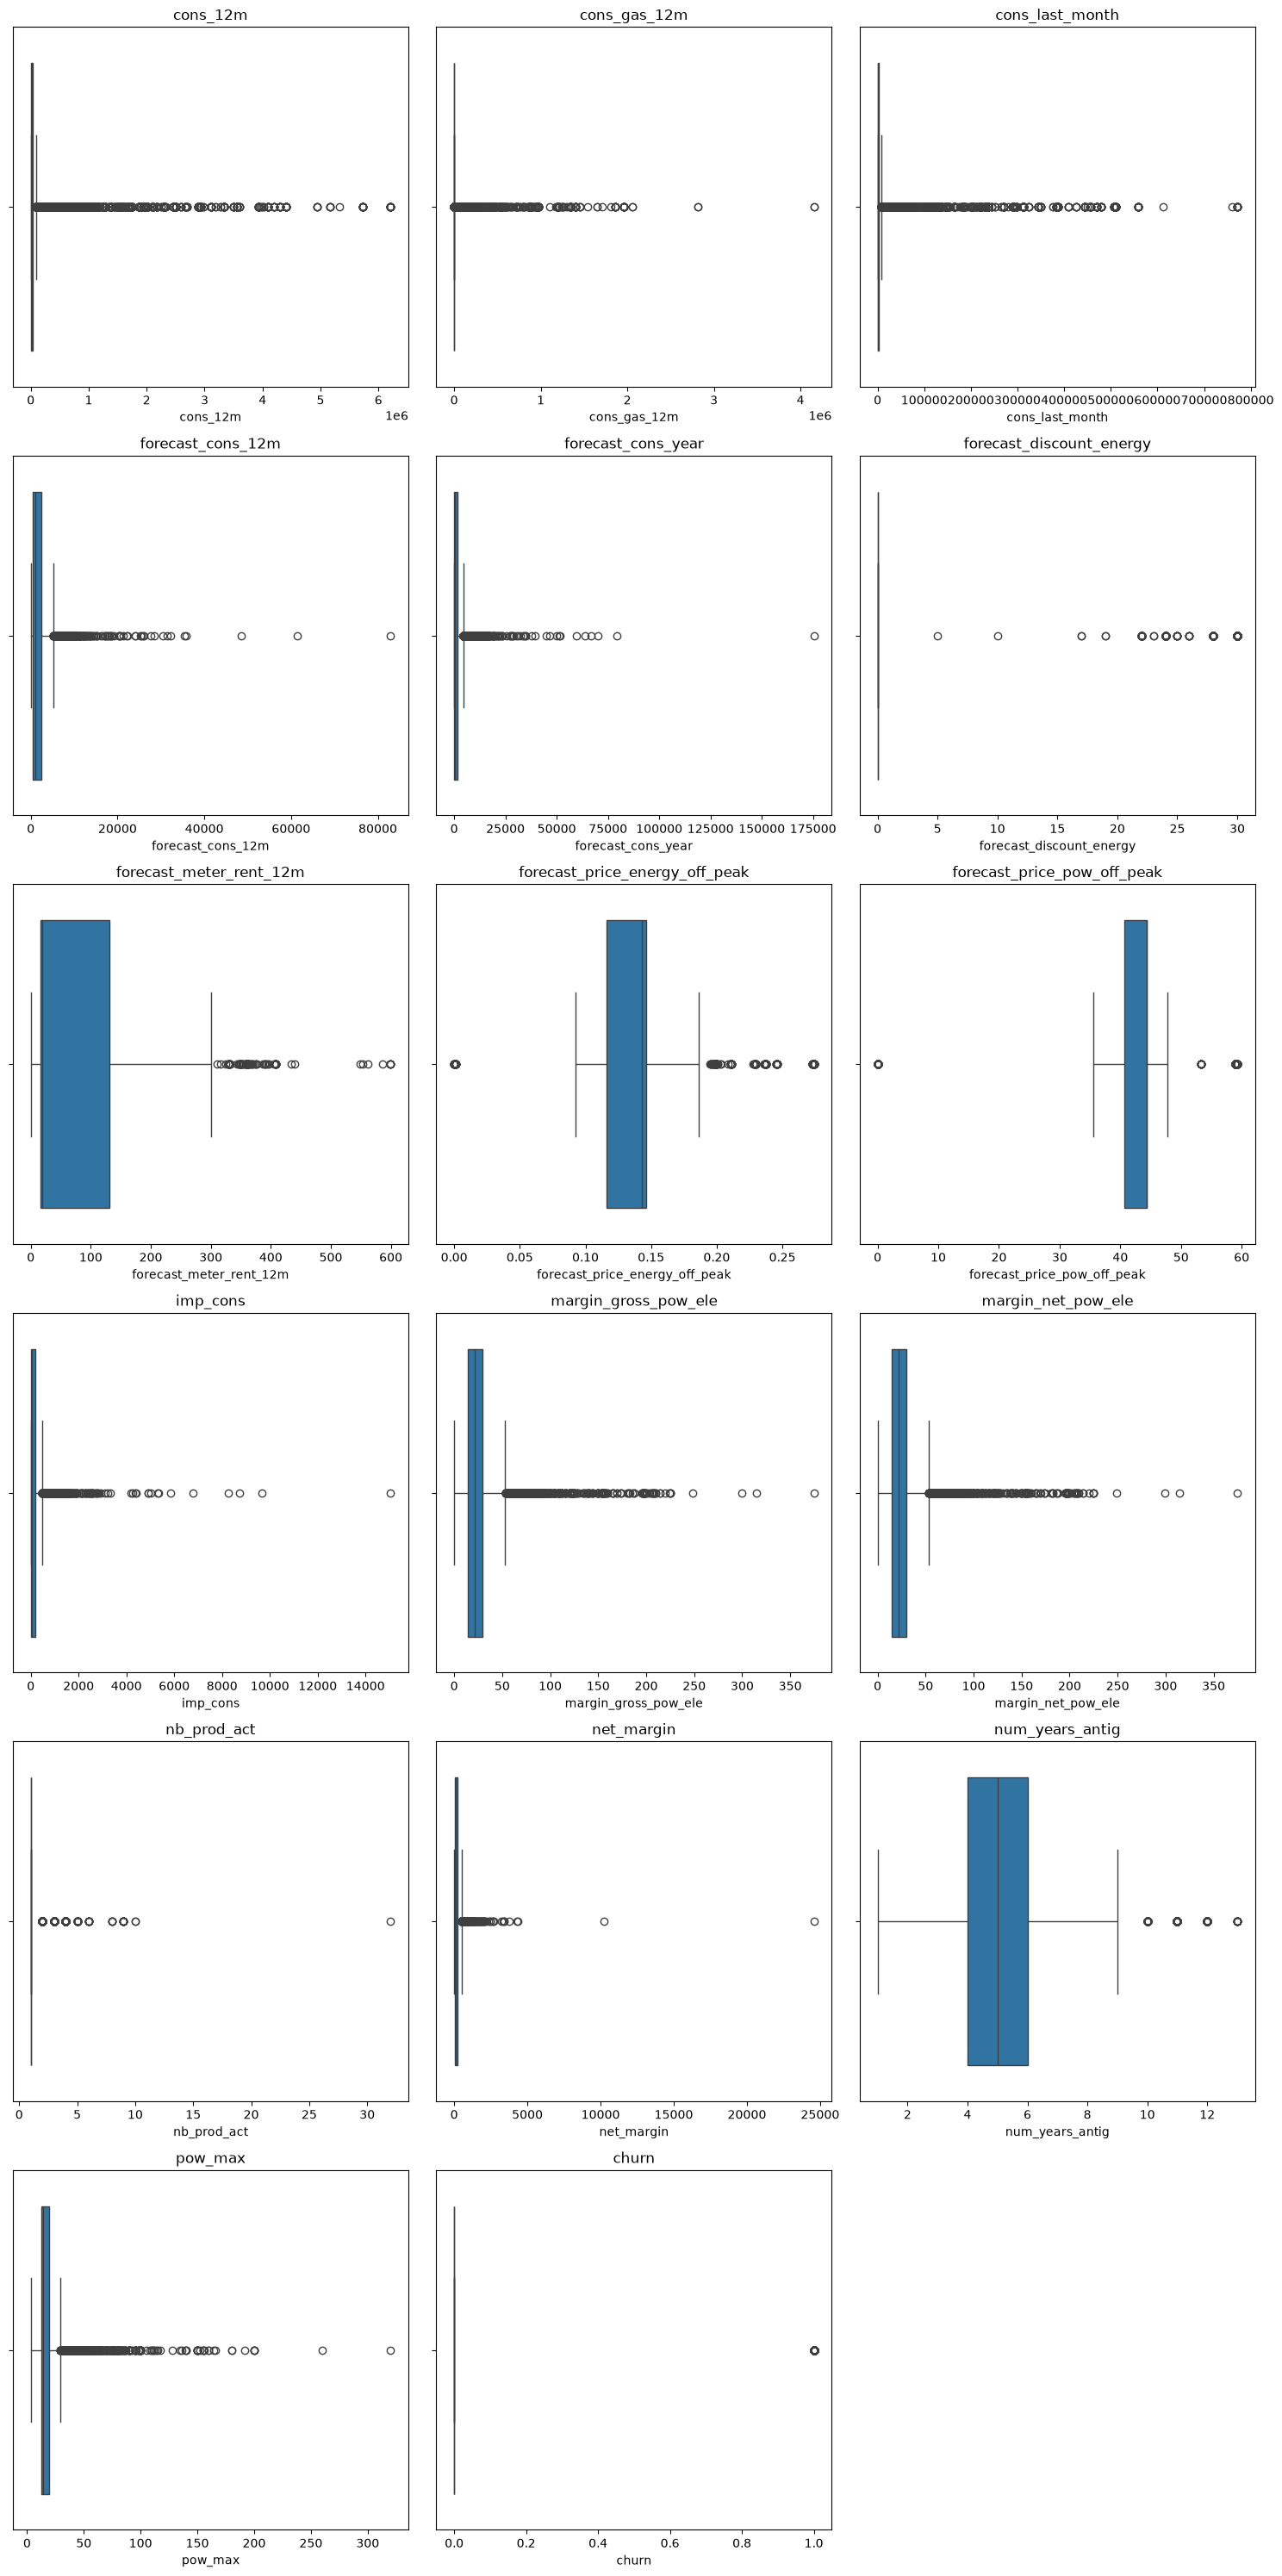

In [17]:
# Check for outliers in the client dataset

# Numerical columns
numeric_cols = client.select_dtypes(include=['int64', 'float64']).columns

# Store columns with outliers
outlier_cols = []

for col in numeric_cols:
    Q1 = client[col].quantile(0.25)
    Q3 = client[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((client[col] < lower) | (client[col] > upper)).sum()

    if outliers > 0:
        outlier_cols.append(col)
        print(f"{col}: {outliers} outliers")

# Plot boxplots for all columns with outliers
n_cols = 3  # plots per row
n_rows = (len(outlier_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=client[col])
    plt.title(col)

plt.tight_layout()
plt.show()

price_off_peak_var: 5633 outliers
price_off_peak_fix: 10452 outliers


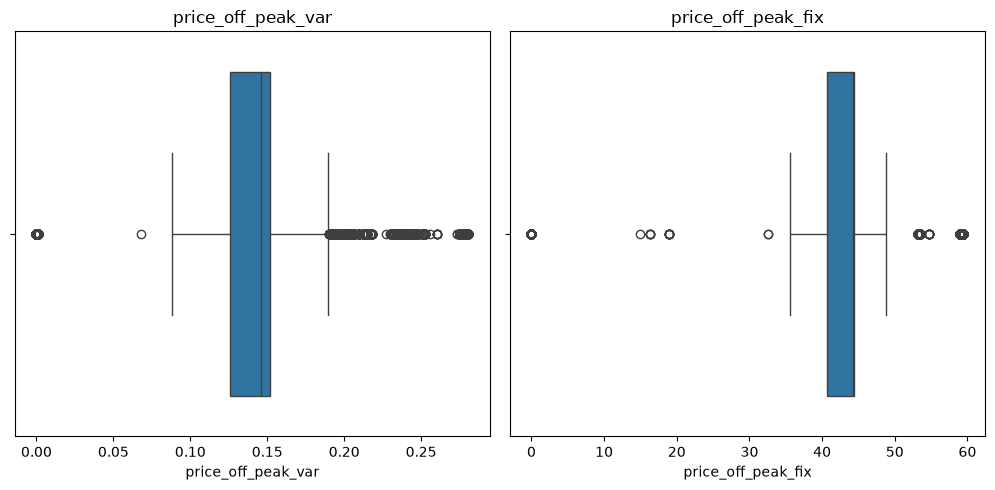

In [18]:
# Check for outliers in the price dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns
numeric_cols = price.select_dtypes(include=['int64', 'float64']).columns

# Store columns with outliers
outlier_cols = []

for col in numeric_cols:
    Q1 = price[col].quantile(0.25)
    Q3 = price[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((price[col] < lower) | (price[col] > upper)).sum()

    if outliers > 0:
        outlier_cols.append(col)
        print(f"{col}: {outliers} outliers")

# Plot boxplots
n_cols = 3
n_rows = (len(outlier_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=price[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Outliers were identified using the InterQuartile Range method and visualised with boxplots.The detected outliers were retained as they represented rela customer consumption behaviour therefore retaining them maintained data integrity and avoided loss of predictive information. 

In the client dataset some features had more outliers in the upper end of the distributions like the annual consumption(cons_12m), annual gas consumption(cons_gas_12m) and monthly consumption(cons_lastmonth) and forecasted prices indicating high usage in some customers while some had moderate outliers.

In the price dataset has outliers on both upper and lower end and they are small in number .The outliers indiate stable pricing as they are clustered around the median.


5. Skewness

net_margin                        36.569515
forecast_cons_year                16.587990
imp_cons                          13.198799
cons_gas_12m                       9.597530
nb_prod_act                        8.636878
forecast_cons_12m                  7.155853
cons_last_month                    6.391407
cons_12m                           5.997308
pow_max                            5.786785
forecast_discount_energy           5.155098
margin_net_pow_ele                 4.473326
margin_gross_pow_ele               4.472632
churn                              2.720715
forecast_meter_rent_12m            1.505148
num_years_antig                    1.446214
forecast_price_energy_peak        -0.014331
forecast_price_energy_off_peak    -0.119586
forecast_price_pow_off_peak       -4.998772
dtype: float64
net_margin                     36.569515
forecast_cons_year             16.587990
imp_cons                       13.198799
cons_gas_12m                    9.597530
nb_prod_act                  

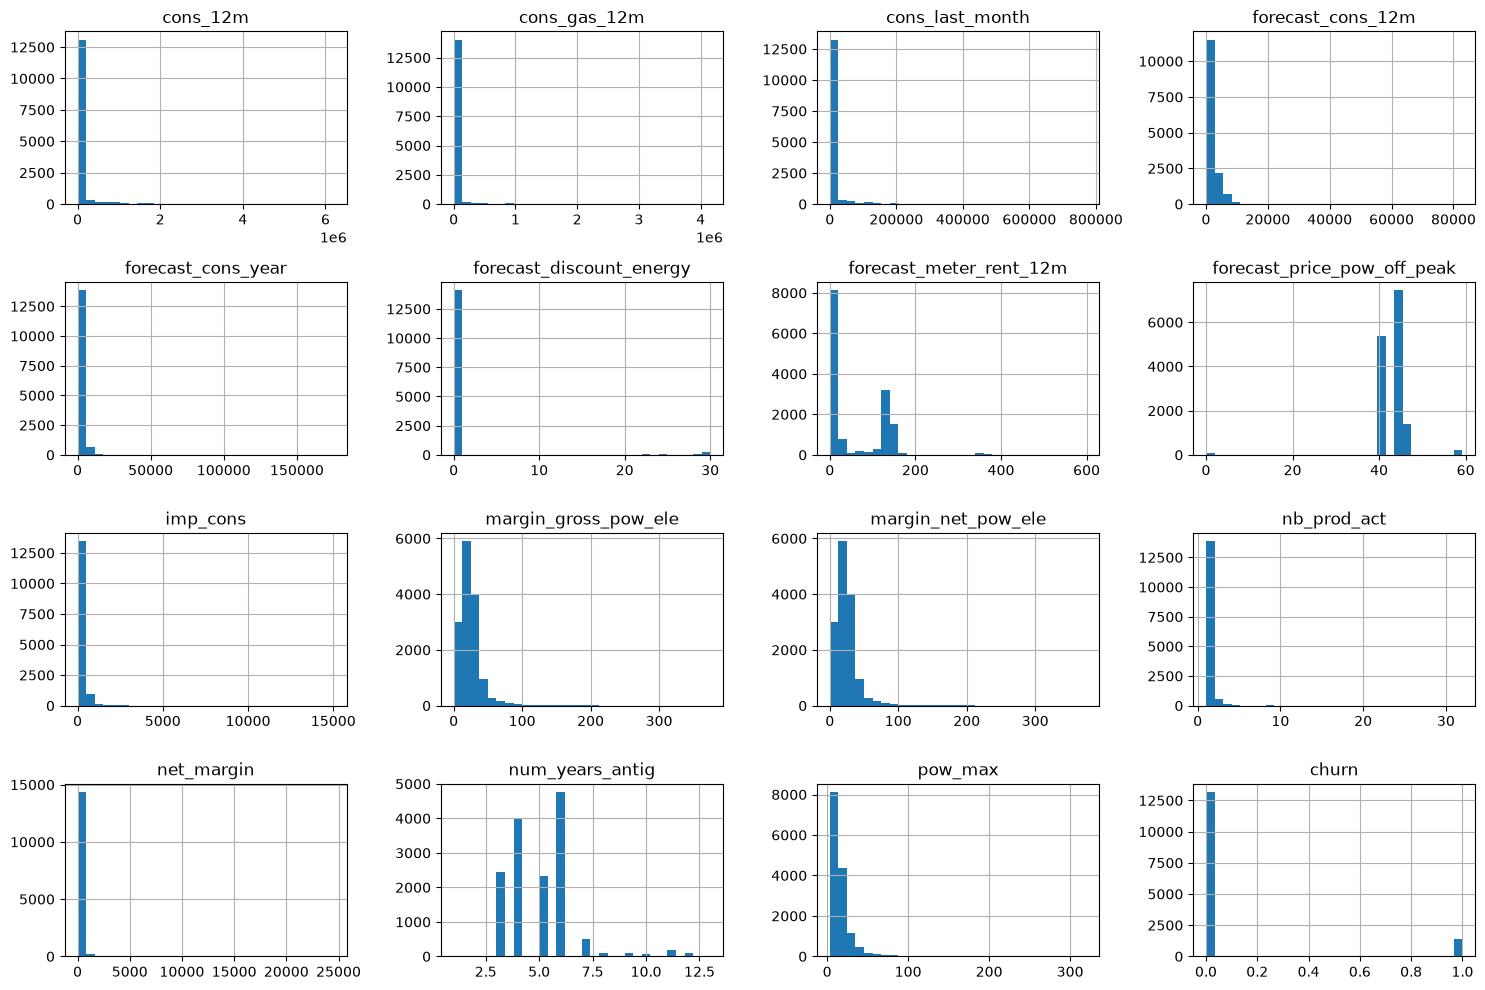

In [19]:
# Skewness of client dataset

# Skewness of numerical columns
skewness = client.select_dtypes(include=['int64', 'float64']).skew()

print(skewness.sort_values(ascending=False))

# identify columns with high skewness (absolute skewness > 1)
skewness = client.select_dtypes(include=['int64', 'float64']).skew()

high_skew = skewness[abs(skewness) > 1]

print(high_skew.sort_values(ascending=False))
# visualize the skewness of numerical columns
import matplotlib.pyplot as plt

high_skew_cols = high_skew.index

client[high_skew_cols].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

Numerical variables like annual consumption(cons_12m),gas consumption(cons_gas_12m),monthly consumption(cons_last_month), forecasted consumption,net margin and maximum power have strong positive skeweness since the values cluster on the lower values with a long tail exteeding to the right.These  indicated that some customers had high consumption rates.

The forecast price for off peak is high negatively skewed distribution(left skewed) meaning a stable pricing across all customers.


price_peak_fix        0.471709
price_mid_peak_fix    0.433076
price_mid_peak_var    0.365508
price_peak_var       -0.133292
price_off_peak_var   -0.311879
price_off_peak_fix   -2.889775
dtype: float64
Highly skewed variables:
price_off_peak_fix   -2.889775
dtype: float64


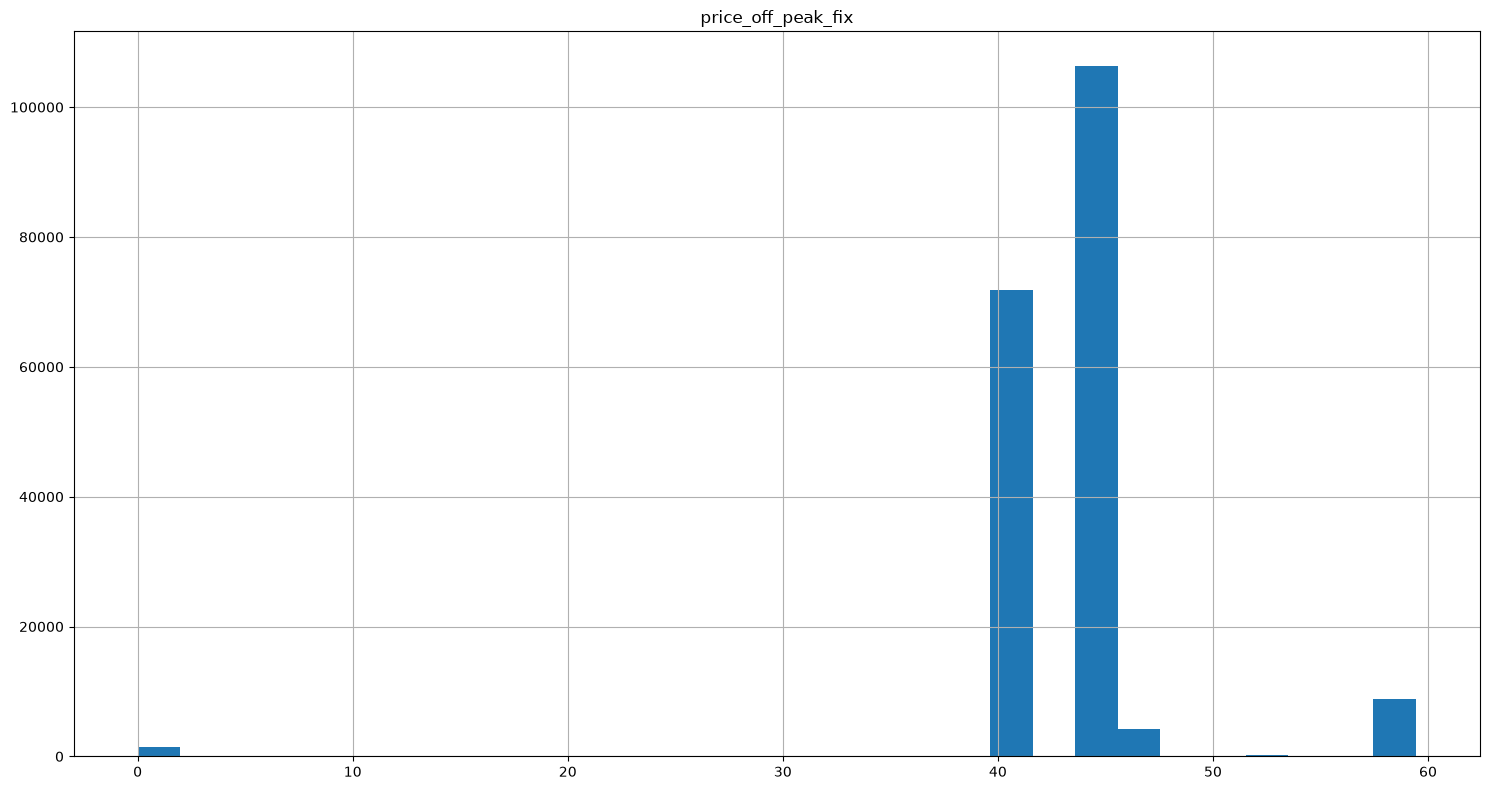

In [20]:
# skewness of price dataset

# Calculate skewness for all numerical columns
skewness = price.select_dtypes(include=['int64', 'float64']).skew()

print(skewness.sort_values(ascending=False))

# identify columns with high skewness (absolute skewness > 1)
high_skew = skewness[abs(skewness) > 1]

print("Highly skewed variables:")
print(high_skew.sort_values(ascending=False))

# visualize the skewness of numerical columns
import matplotlib.pyplot as plt

high_skew_cols = high_skew.index

price[high_skew_cols].hist(
    figsize=(15, 8),
    bins=30
)

plt.tight_layout()
plt.show()

Off peak fixed price was negatively skewed  with most values between 40 and 46. This indicated a stable off peak  pricing for customers with fewer customers paying more.

6. Class imbalance

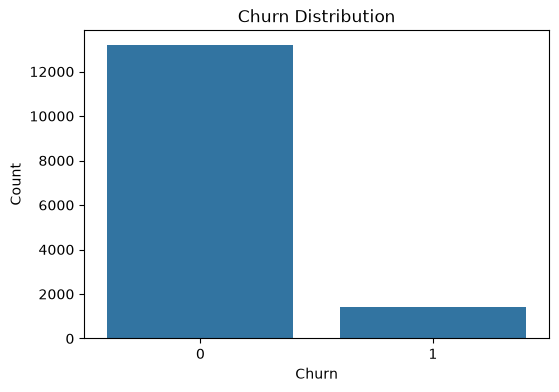

In [21]:
# Check the distribution of the target variable 'churn'
client['churn'].value_counts()

# Check the distribution of the target variable 'churn' in percentage
client['churn'].value_counts(normalize=True) * 100

# visualize the class distribution of the target variable 'churn'
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=client)

plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')

plt.show()

In [22]:
# Create a DataFrame to display the counts and percentages of churn classes
churn_counts = client['churn'].value_counts()
churn_percent = client['churn'].value_counts(normalize=True) * 100

print(pd.DataFrame({
    'Count': churn_counts,
    'Percentage': churn_percent.round(2)
}))

       Count  Percentage
churn                   
0      13187       90.28
1       1419        9.72


Class imbalance was assesed by examining churn distribution.
Results indicated thta majority of customers did not churn(90%) while only 10% did.This showed a class imbalance where the minority (churned customers) is underrepresented compared to the majority(retained customers),thereby mya cause models to favour majority class.

Linear Separability

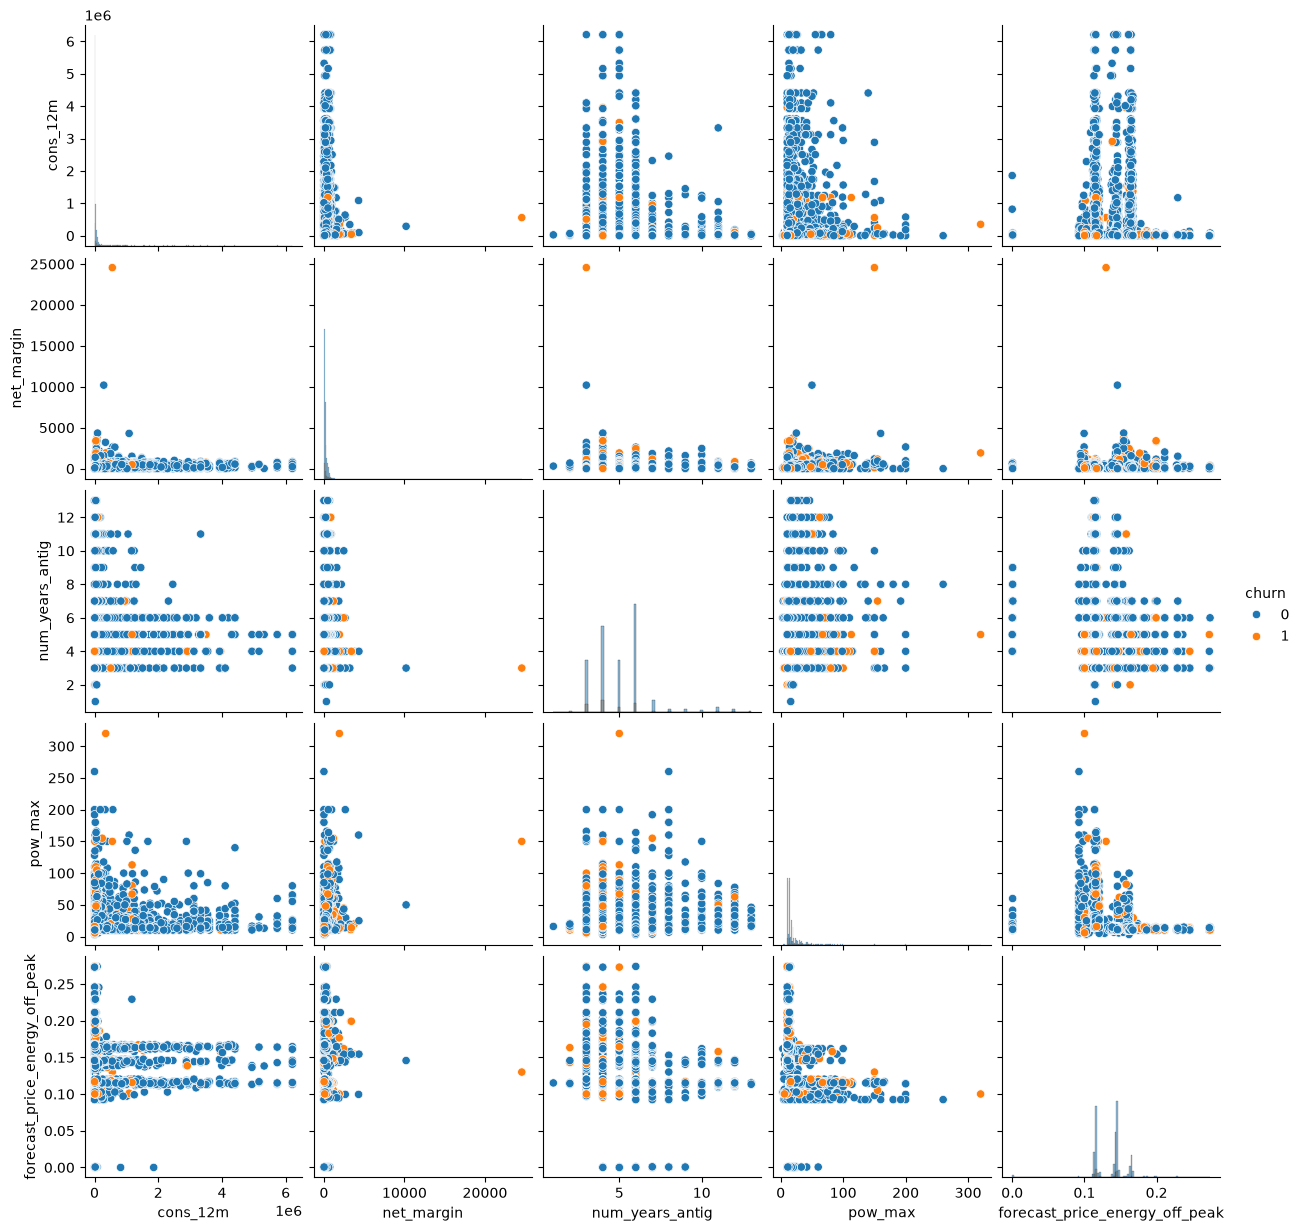

In [28]:
# plot pairplot to visualize the relationships between selected features and the target variable 'churn'
import seaborn as sns
import matplotlib.pyplot as plt

selected_features = [
    'cons_12m',
    'net_margin',
    'num_years_antig',
    'pow_max',
    'churn',
    'price_12m'
]

selected_features = [
    'cons_12m',
    'net_margin',
    'num_years_antig',
    'pow_max',
    'churn',
    'forecast_price_energy_off_peak'
]

sns.pairplot(
    client[selected_features],
    hue='churn',
    diag_kind='hist'
)



plt.show()

Linear separability between churn and non churn customers was assesed by pairplot.

The visualisation indicated lack of linear separability  between the churn classes where 0= no churn and 1= churn.
This suggested that custoer churn is influenced by complex relationship between variables and that non linear models would be suitble in predictig  customer churn.

## Data Merging

In [29]:
# Merge the client and price datasets on the 'id' column

client_price = pd.merge(
    client,
    price,
    on='id',
    how='left'
)

In [30]:
# Save the merged dataset to a new CSV file

client_price.to_csv('client_price_data.csv', index=False)

Merged the two disparate datasets on id column to aid in data analysis.

## Feature Engineering

In [33]:
# Average Monthly Consumption

client['avg_monthly_cons'] = client['cons_12m'] / 12


In [34]:
# Consumption Trend Ratio

client['cons_trend_ratio'] = (client['cons_last_month']/ client['avg_monthly_cons'])

In [35]:
# Contract Duration

client['contract_duration_days'] = (client['date_end'] - client['date_activ']).dt.days



In [36]:
# Customer Tenure

client['customer_tenure'] = (pd.Timestamp.today() - client['date_activ']).dt.days

Calculated average monthly consumption ,consumption trend ration,contract duration and customer tenure to aid in data analysis of customer consumption pattern,customer longevity and contract characteristics that influence churn behaviour.

## Visualisation

 1. Churn Analysis

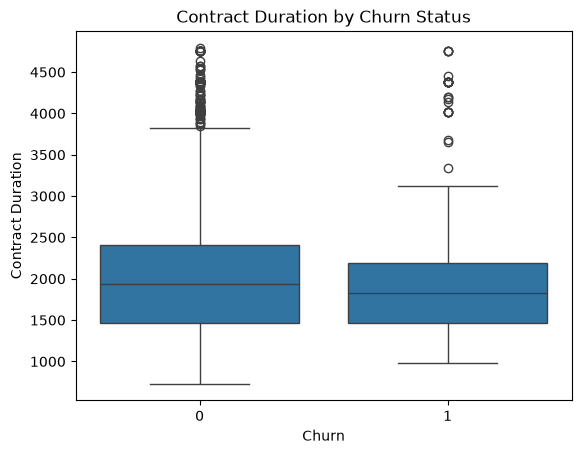

In [37]:
sns.boxplot(x='churn', y='contract_duration_days', data=client)

plt.title('Contract Duration by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Contract Duration')
plt.show()

Non churn customers (churn = 0) have longer contract durations compared to churned customers(churn = 1) who have shorter contract durations .This suggested that longer sintracts duration contribute to customer retention and reduce the likelihood of churning.

The overlapping between the two customers class suggested that contract duration is not a strong predictor of customer churn.


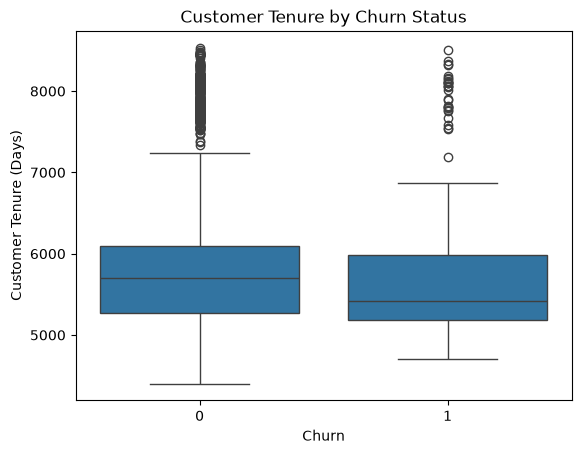

In [38]:
sns.boxplot(x='churn', y='customer_tenure', data=client)

plt.title('Customer Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Customer Tenure (Days)')
plt.show()

Non churn customers (churn = 0) have slightly longer tenure compared to churn (churn =1) customers.This indicated that longer standing customers are less likely  to churn.

The overlap between the tenure distribution of the two indicates that customer tenure alone is not a stronger churn predictor.

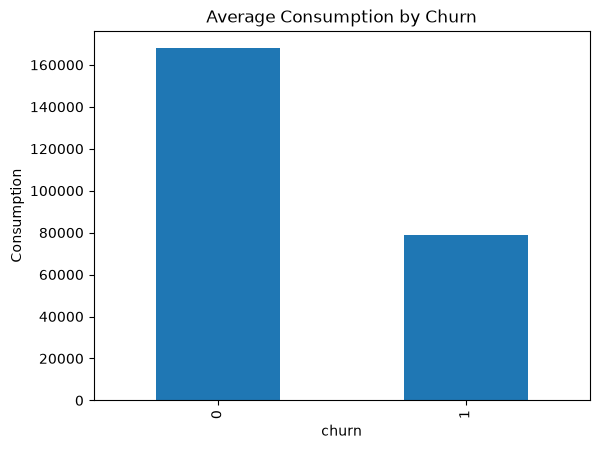

In [39]:
# Average Consumption by Churn

client.groupby('churn')['cons_12m'].mean().plot(kind='bar')
plt.title('Average Consumption by Churn')
plt.ylabel('Consumption')
plt.show()

Non churning customers have higher average energy consumption compared to the churning customers.Also, the non churnnig customers consume twice as much energy on average as churning customers.This suggests that customers with high consumption patterns may be dependent on the service and therefore less likely to switch providers compared with customers with less consumption patters who are more likely to churn.

.This suggest indicating that usage  behaviour may influence retention decisions.

The customer retained prevailed thereby highlighting high retention rate.

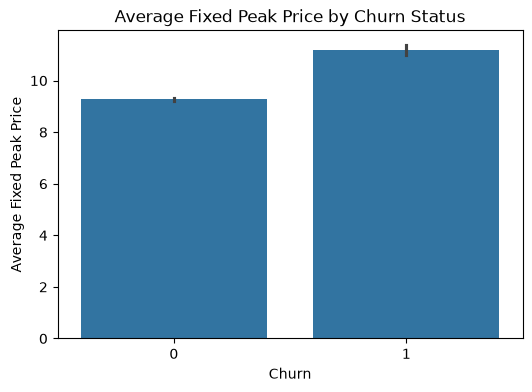

In [40]:
plt.figure(figsize=(6,4))
sns.barplot(x='churn', y='price_peak_fix', data=client_price)

plt.title('Average Fixed Peak Price by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Average Fixed Peak Price')
plt.show()

Churning customers were charged higher fixed peak price on averga compared to non churning customers. This suggests that higher fixed peak pricing increased the likelihood of churning ,because acustomers face higher charge they may develop sensitivity to energy cost and being more inclined to switch providers.

This suggests pricing influence customer churn or retention.

2. Consumption Analysis 

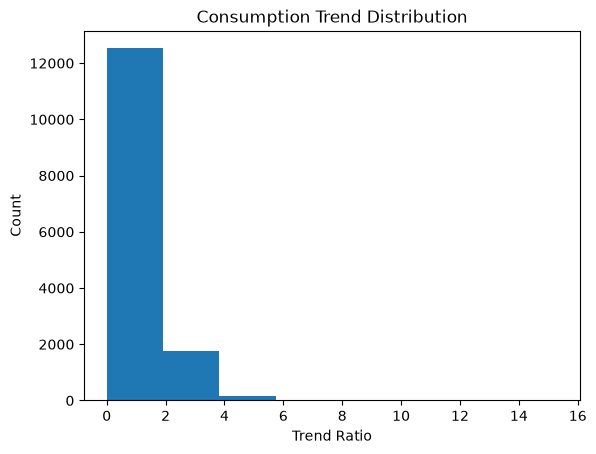

In [41]:
# Consumption Trend Distribution

plt.hist(client['cons_trend_ratio'], bins=8)
plt.title('Consumption Trend Distribution')
plt.xlabel('Trend Ratio')
plt.ylabel('Count')
plt.show()

The distribution is highly positively skewed with a long right tail indicating increased consumption in some cistomers compared to most of the custoemrs.Only a small number of cutomers have trend ratio greater than 2 and a few exceed 4.

Most customers maintain relatively stable consumption over time, while extreme ratios may indicate changing energy needs or customer dissatisfaction.

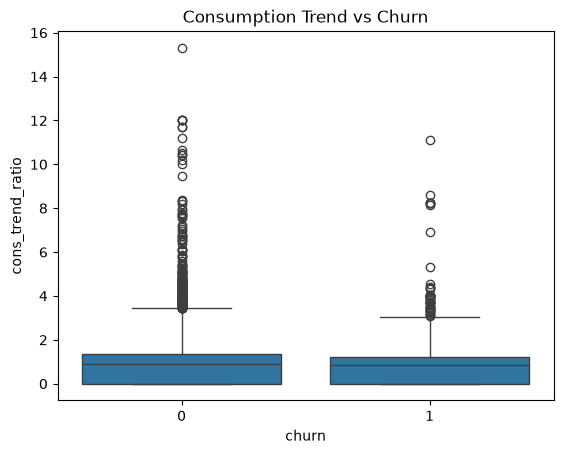

In [42]:
# Consumption Trend vs Churn

sns.boxplot(x='churn', y='cons_trend_ratio', data=client)
plt.title('Consumption Trend vs Churn')
plt.show()


Both churning and non churnig customers have similar median values indicating comparable consumption trends across the 2 customers.This indicated consumption trend ratio alone can not predict customerr churn analysis. 

Presence of extreme outliers vlaues indicate that ustomers experiencing significant fluctuations in consumption may be more prone to switching providers.



3. Pricing Analysis

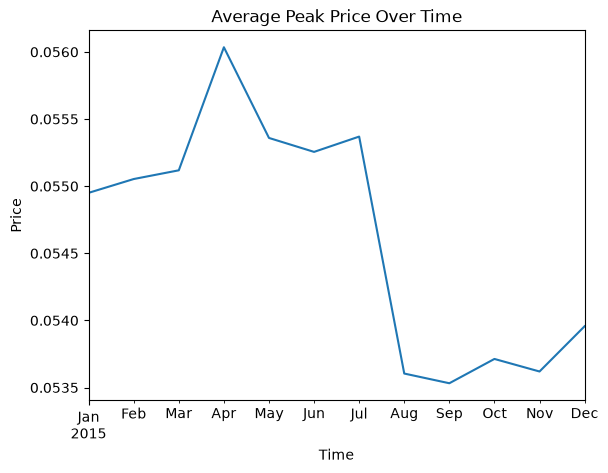

In [43]:
# Average Peak Price Over Time

price_trend = price.groupby('price_date')['price_peak_var'].mean()

price_trend.plot()
plt.title('Average Peak Price Over Time')
plt.xlabel('Time')
plt.ylabel('Price')
plt.show()


The price increased gradually from January to April before declining slightly and noticeable drop in August.After this decline,the peak prices remained relatively constant for the rest of the year. 

The overall variation was small suggesting a fairly consistent peak electricity prices.

4.Forecast vs Actual Consumption

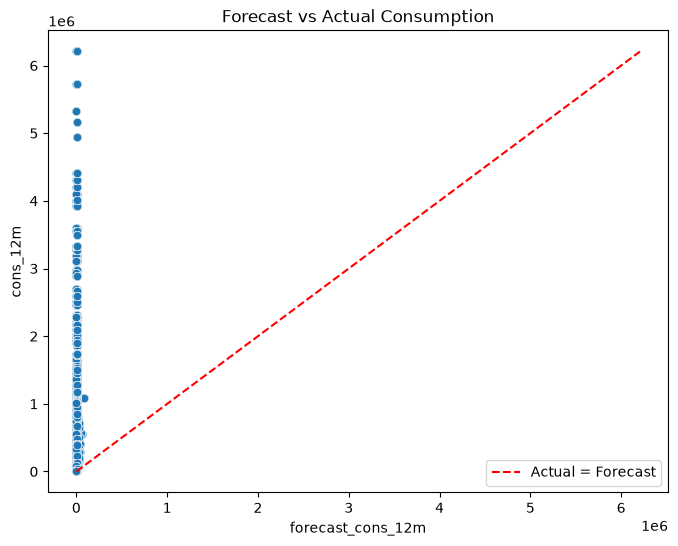

In [44]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='forecast_cons_12m',
    y='cons_12m',
    data=client_price,
    alpha=0.5
)

max_val = max(
    client_price['forecast_cons_12m'].max(),
    client_price['cons_12m'].max()
)

plt.plot(
    [0, max_val],
    [0, max_val],
    color='red',
    linestyle='--',
    label='Actual = Forecast'
)

plt.legend()
plt.title('Forecast vs Actual Consumption')
plt.show()

Most observations are above the reference line indicating that the actual consumption is greater than the forecasted consumption.

Many customers consume more energy thatn the forecasted  on suggesting difficulty in predicting customer consumption behaviour.

Several outliers were seen indicating variation in customer energy consumption.



5. Time Based Analysis

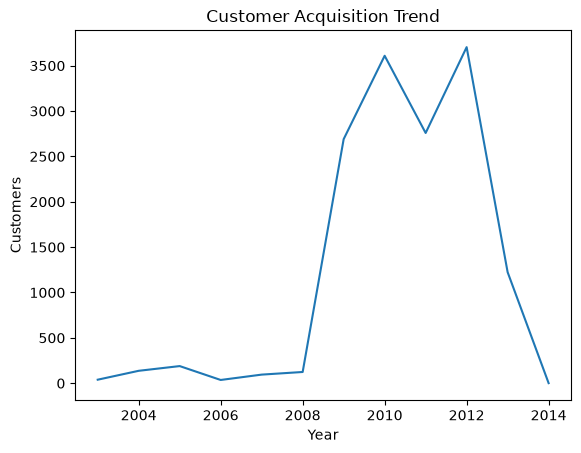

In [45]:
# Customer Acquisition Trend 

client['date_activ'].dt.year.value_counts().sort_index().plot()

plt.title('Customer Acquisition Trend')
plt.xlabel('Year')
plt.ylabel('Customers')
plt.show()

A rapid customer growth between 2008 and 2012 was experienced by the company , suggesting succesful customer acquisition.

A notable decline after 312 indicated a slowdown in customer acquisition.

These affects customer retention and churning behaviour.

6. Correlation Analysis

cons_12m                    avg_monthly_cons              1.000000
avg_monthly_cons            cons_12m                      1.000000
margin_net_pow_ele          margin_gross_pow_ele          0.999914
margin_gross_pow_ele        margin_net_pow_ele            0.999914
customer_tenure             contract_duration_days        0.984300
contract_duration_days      customer_tenure               0.984300
customer_tenure             num_years_antig               0.984149
num_years_antig             customer_tenure               0.984149
imp_cons                    forecast_cons_year            0.969395
forecast_cons_year          imp_cons                      0.969395
cons_last_month             avg_monthly_cons              0.968212
avg_monthly_cons            cons_last_month               0.968212
cons_last_month             cons_12m                      0.968212
cons_12m                    cons_last_month               0.968212
num_years_antig             contract_duration_days        0.95

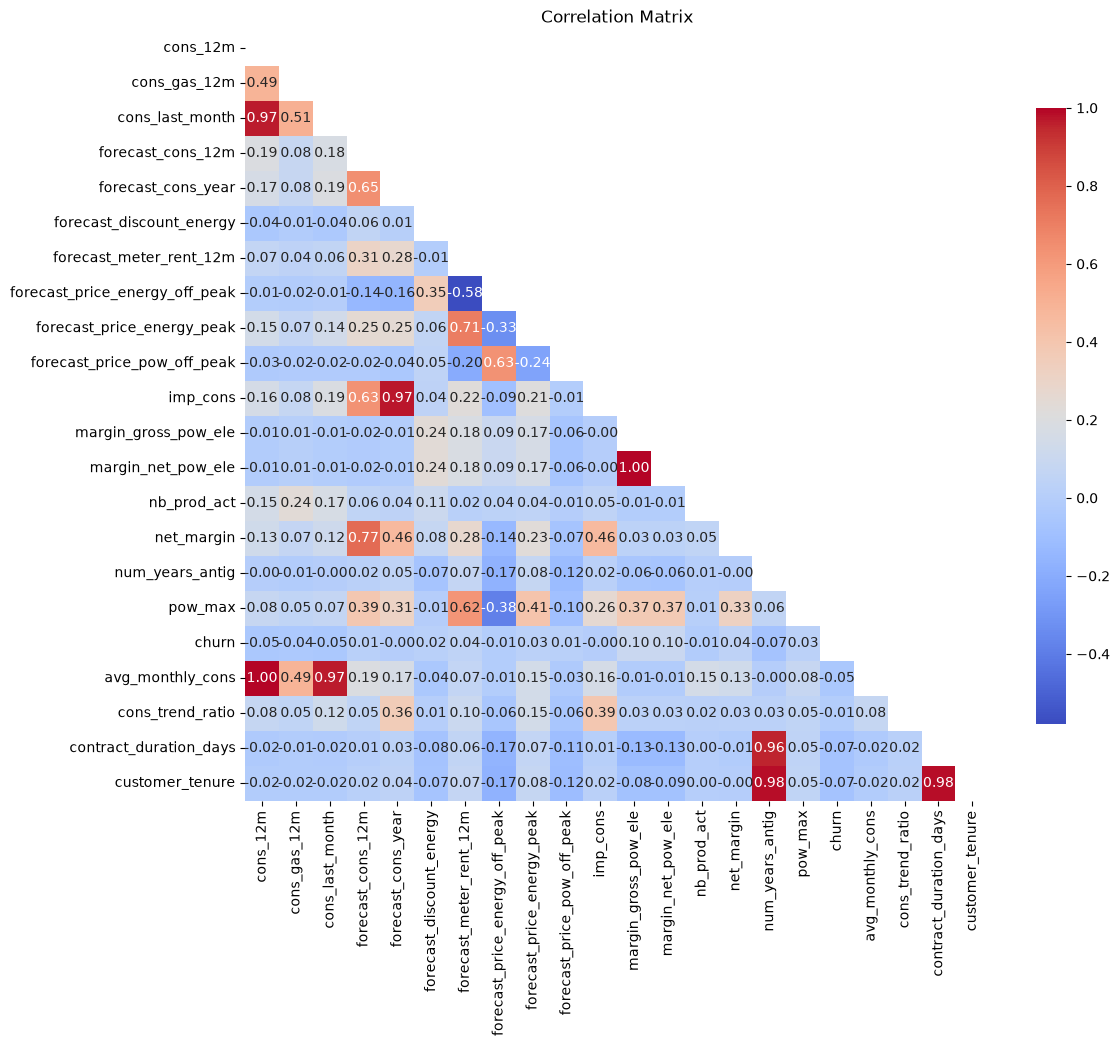

In [46]:
corr_matrix = client.corr(numeric_only=True)

strong_corr = corr_matrix.unstack()
strong_corr = strong_corr[(abs(strong_corr) > 0.7) & (abs(strong_corr) < 1)]

print(strong_corr.sort_values(ascending=False))


corr_matrix = client.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Matrix')
plt.show()


In [47]:
corr_matrix = client.corr(numeric_only=True)

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) > 0.8:
            high_corr_pairs.append(
                (
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    round(corr_value, 2)
                )
            )

for pair in high_corr_pairs:
    print(pair)

('cons_12m', 'cons_last_month', np.float64(0.97))
('cons_12m', 'avg_monthly_cons', np.float64(1.0))
('cons_last_month', 'avg_monthly_cons', np.float64(0.97))
('forecast_cons_year', 'imp_cons', np.float64(0.97))
('margin_gross_pow_ele', 'margin_net_pow_ele', np.float64(1.0))
('num_years_antig', 'contract_duration_days', np.float64(0.96))
('num_years_antig', 'customer_tenure', np.float64(0.98))
('contract_duration_days', 'customer_tenure', np.float64(0.98))


Several variables exhibited high multicollinearity (strong correlation with each other). To reduce redundancy and prevent biased model estimates, one variable from each highly correlated pair was removed before model training.

## Modeling

In [48]:
# Data Preparation for Modeling

# Remove variables with high multicollinearity
client_price = client_price.drop(
    columns=[
        'avg_monthly_cons',
        'margin_net_pow_ele',
        'num_years_antig',
        'contract_duration_days',
        'imp_cons'
    ],
    errors='ignore'
)

# Target variable
X = client_price.drop('churn', axis=1)
y = client_price['churn']

# Check dimensions
print(X.shape)
print(y.shape)

(175149, 29)
(175149,)


In [49]:
# Encoding categorical variables using LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(exclude='object'):
    X[col] = le.fit_transform(X[col].astype(str))

In [50]:
# Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# Model training and Evaluation

In [51]:
# Logistic Regression Model training and evaluation

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

# Prepare numeric features for Logistic Regression

X_train = X_train.drop(columns=['id']).copy()
X_test = X_test.drop(columns=['id']).copy()

date_cols = [
    'date_activ',
    'date_end',
    'date_modif_prod',
    'date_renewal',
    'price_date'
]

for col in date_cols:
    if col in X_train.columns:
        train_dates = pd.to_datetime(X_train[col], errors='coerce')
        test_dates = pd.to_datetime(X_test[col], errors='coerce')

        X_train[col] = train_dates.map(lambda x: x.toordinal() if pd.notna(x) else np.nan)
        X_test[col] = test_dates.map(lambda x: x.toordinal() if pd.notna(x) else np.nan)

# Encode categorical columns consistently
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Replace missing and infinite values
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

print(confusion_matrix(y_test, lr_pred))



Accuracy: 0.9029117898943763
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     31629
           1       0.00      0.00      0.00      3401

    accuracy                           0.90     35030
   macro avg       0.45      0.50      0.47     35030
weighted avg       0.82      0.90      0.86     35030

[[31629     0]
 [ 3401     0]]


Although the model achieved 90.3% accuracy, it completely failed to identify customers who churned. All customers were classified as non-churners, resulting in a churn recall of 0%. Therefore, the model has no practical value for churn prediction because it cannot detect the customers the business aims to retain

In [52]:
# Random Forest model training and evaluation

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

print(classification_report(y_test,predictions))

print(confusion_matrix(y_test,predictions))

Accuracy: 0.9998572652012561
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     31629
           1       1.00      1.00      1.00      3401

    accuracy                           1.00     35030
   macro avg       1.00      1.00      1.00     35030
weighted avg       1.00      1.00      1.00     35030

[[31629     0]
 [    5  3396]]


The model achieved an accuracy of 99.99%, indicating excellent predictive performance. The confusion matrix shows that all 31,629 non-churn customers were correctly classified, while 3,396 out of 3,401 churn customers were correctly identified. Only five churn cases were misclassified as non-churn, and there were no false positives. 

The model achieved near-perfect precision, recall, and F1-scores for both classes. These results suggest that the model is highly effective at distinguishing between churners and non-churners

In [53]:
# XGBoost model training and evaluation

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

print(confusion_matrix(y_test, xgb_pred))

Accuracy: 0.9503282900371111
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     31629
           1       1.00      0.49      0.66      3401

    accuracy                           0.95     35030
   macro avg       0.97      0.75      0.82     35030
weighted avg       0.95      0.95      0.94     35030

[[31622     7]
 [ 1733  1668]]


The model achieved 95.03% accuracy, correctly classifying most customers. It identified 1,668 of the 3,401 churn customers (recall = 49%) while correctly classifying almost all non-churn customers. 

The model produced only 7 false positives, resulting in a precision of 100% for the churn class. However, it missed 1,733 churn customers, indicating that while churn predictions are highly reliable, the model fails to detect a substantial proportion of actual churners.

## Model Comparison

In [54]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, predictions),
        accuracy_score(y_test, xgb_pred)
    ]
})

model_results

model_results

,Model,Accuracy
0,Logistic Regression,0.902912
1,Random Forest,0.999857
2,XGBoost,0.950328


Three machine learning models were evaluated for customer churn prediction: Logistic Regression, Random Forest, and XGBoost. Logistic Regression achieved an accuracy of 90.29% but failed to identify any churning customers, making it unsuitable for the churn prediction task. XGBoost improved performance with an accuracy of 95.03%, successfully identifying 49% of churners while maintaining high precision. Random Forest achieved the highest accuracy of 99.99% and near-perfect classification performance, correctly identifying almost all churn and non-churn customers. 

Based on these results, Random Forest emerged as the best-performing model for churn prediction.

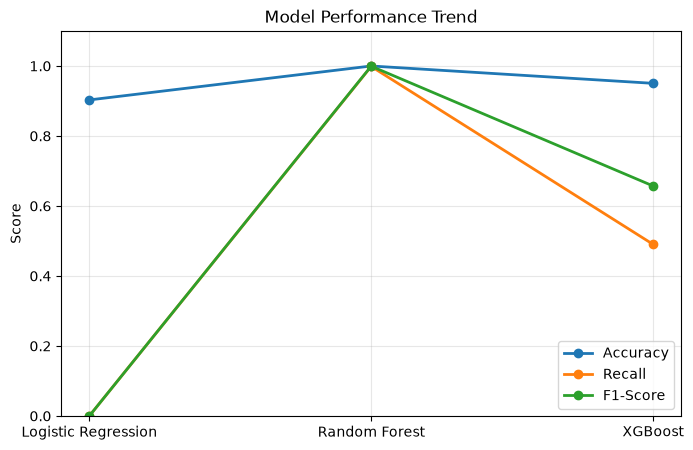

In [56]:
from sklearn.metrics import recall_score, f1_score

plt.figure(figsize=(8,5))

model_predictions = {
    'Logistic Regression': lr_pred,
    'Random Forest': predictions,
    'XGBoost': xgb_pred
}

model_results = pd.DataFrame({
    'Model': list(model_predictions.keys()),
    'Accuracy': [
        accuracy_score(y_test, pred)
        for pred in model_predictions.values()
    ],
    'Recall': [
        recall_score(y_test, pred, zero_division=0)
        for pred in model_predictions.values()
    ],
    'F1-Score': [
        f1_score(y_test, pred, zero_division=0)
        for pred in model_predictions.values()
    ]
})

plt.plot(
    model_results['Model'],
    model_results['Accuracy'],
    marker='o',
    linewidth=2,
    label='Accuracy'
)

plt.plot(
    model_results['Model'],
    model_results['Recall'],
    marker='o',
    linewidth=2,
    label='Recall'
)

plt.plot(
    model_results['Model'],
    model_results['F1-Score'],
    marker='o',
    linewidth=2,
    label='F1-Score'
)

plt.title('Model Performance Trend')
plt.ylabel('Score')
plt.ylim(0,1.1)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


The graph shows that Random Forest outperformed both Logistic Regression and XGBoost across all evaluation metrics. Random Forest achieved the highest accuracy, recall, and F1-score, indicating superior ability to correctly classify both churning and non-churning customers.

Logistic Regression achieved relatively high accuracy (about 90%), but its recall and F1-score were close to zero. This suggests that although it correctly classified many customers overall, it failed to identify churners effectively.

XGBoost achieved higher accuracy than Logistic Regression and substantially better recall and F1-score, showing a stronger ability to detect churners. However, its performance remained below that of Random Forest, particularly in recall and F1-score.

Overall, the graph indicates that Random Forest is the most effective model for churn prediction, providing the best balance between overall accuracy and correct identification of churn customers.



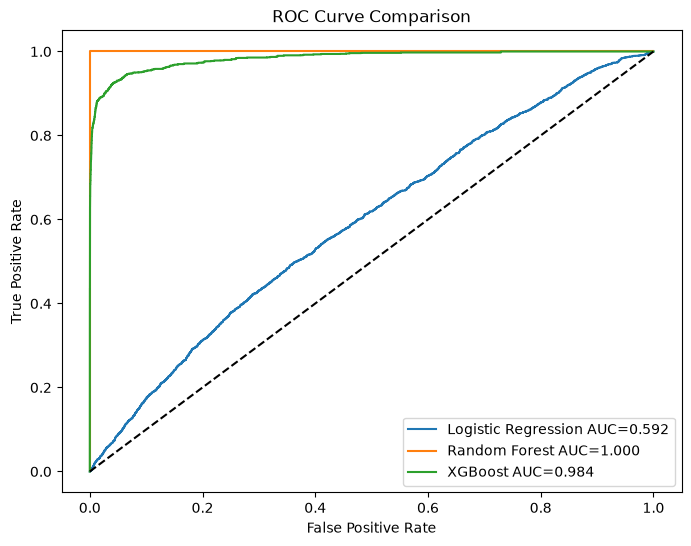

In [57]:
# ROC Curve Comparison

from sklearn.metrics import roc_curve, auc

lr_probs = lr.predict_proba(X_test)[:,1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb.predict_proba(X_test)[:,1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f'Logistic Regression AUC={auc(lr_fpr, lr_tpr):.3f}'
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest AUC={auc(rf_fpr, rf_tpr):.3f}'
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f'XGBoost AUC={auc(xgb_fpr, xgb_tpr):.3f}'
)

plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()

plt.show()

The ROC curve shows that Random Forest has the strongest ability to distinguish between churners and non-churners, as its curve remains closest to the top-left corner and achieves an AUC of 1.000. This indicates near-perfect classification performance across different threshold values.

XGBoost also performs exceptionally well, with an AUC of 0.984. Its curve closely follows that of Random Forest, indicating a high true positive rate while maintaining a low false positive rate. However, it is slightly less effective than Random Forest.

In contrast, Logistic Regression has an AUC of 0.592, and its ROC curve lies much closer to the diagonal baseline. This suggests limited discriminatory power and indicates that the model performs only slightly better than random classification.

Overall, the graph demonstrates that Random Forest is the best-performing model, followed by XGBoost, while Logistic Regression is the weakest model for predicting customer churn. The higher AUC values of Random Forest and XGBoost indicate their superior ability to correctly identify churners while minimizing misclassification.

## Hyperparameter Tuning



1. Random Forest

In [58]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

rf_random.fit(X_train, y_train)

print(rf_random.best_params_)
print(rf_random.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
1.0


Hyperparameter tuning was performed using RandomizedSearchCV with 5-fold cross-validation, evaluating 20 different parameter combinations (100 total model fits). The optimal Random Forest model was obtained with 300 trees (n_estimators=300), no restriction on tree depth (max_depth=None), a minimum of 2 samples required to split a node (min_samples_split=2), and a minimum of 1 sample per leaf (min_samples_leaf=1). The tuned model achieved an accuracy score of 1.00, indicating near-perfect classification performance on the evaluation dataset.

In [60]:
# Best Random Forest MOdel

best_rf_model = rf_random.best_estimator_

rf_pred = best_rf_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred, zero_division=0))
print("F1-Score:", f1_score(y_test, rf_pred, zero_division=0))

print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))

probabilities = best_rf_model.predict_proba(X_test)[:, 1]

Accuracy: 0.9998572652012561
Recall: 0.9985298441634813
F1-Score: 0.9992643813447109
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     31629
           1       1.00      1.00      1.00      3401

    accuracy                           1.00     35030
   macro avg       1.00      1.00      1.00     35030
weighted avg       1.00      1.00      1.00     35030

[[31629     0]
 [    5  3396]]


After hyperparameter tuning using RandomisedSearchCV, the Random Forest model achieved an accuracy of 99.99%, a recall of 99.85%, and an F1-score of 99.93%. The confusion matrix shows that all 31,629 non-churn customers were correctly classified, while 3,396 of the 3,401 churn customers were correctly identified. Only five churn customers were misclassified, and no non-churn customers were incorrectly predicted as churners. 

These results indicate that the tuned model achieved near-perfect classification performance and was highly effective in distinguishing between churning and non-churning customers.

#### Error Analysis

In [63]:

# Extracting misclassified instances for further analysis 

# Generate predictions using the tuned Random Forest model
y_pred = best_rf_model.predict(X_test)

# Create dataframe for analysis
error_df = X_test.copy()
error_df['Actual'] = y_test.values
error_df['Predicted'] = y_pred

# False Negatives (missed churners)
false_negatives = error_df[
    (error_df['Actual'] == 1) &
    (error_df['Predicted'] == 0)
]

print("Number of False Negatives:", len(false_negatives))
false_negatives.head()

Number of False Negatives: 5


,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,...,has_gas_f,has_gas_t,origin_up_MISSING,origin_up_ewxeelcelemmiwuafmddpobolfuxioce,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw,origin_up_usapbepcfoloekilkwsdiboslwaxobdp,Actual,Predicted
7605,7716,0,3084,719163,719163,735164,735896,9967,2687,0,...,True,False,False,False,False,False,True,False,1,0
155214,7877,0,2381,719163,719163,735229,735960,6634,2044,0,...,True,False,False,False,False,False,True,False,1,0
9306,1701,0,4549,719163,719163,733804,735638,1173,4038,0,...,True,False,False,False,False,False,True,False,1,0
147262,6122,0,1996,719163,719163,735751,735525,7683,1723,0,...,True,False,False,False,False,False,True,False,1,0
126436,2826,0,3843,719163,719163,734716,735964,4651,0,0,...,True,False,False,False,False,False,True,False,1,0


In [64]:
# characteristics of False Negatives

false_negatives.describe().T

,count,mean,std,min,25%,50%,75%,max
cons_12m,5.0,5248.4,2837.861572,1701.0,2826.0,6122.0,7716.0,7877.0
cons_gas_12m,5.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
cons_last_month,5.0,3170.6,1044.361192,1996.0,2381.0,3084.0,3843.0,4549.0
date_activ,5.0,719163.0,0.000000,719163.0,719163.0,719163.0,719163.0,719163.0
date_end,5.0,719163.0,0.000000,719163.0,719163.0,719163.0,719163.0,719163.0
date_modif_prod,5.0,734932.8,730.039519,733804.0,734716.0,735164.0,735229.0,735751.0
date_renewal,5.0,735796.6,202.190010,735525.0,735638.0,735896.0,735960.0,735964.0
forecast_cons_12m,5.0,6021.6,3319.974819,1173.0,4651.0,6634.0,7683.0,9967.0
forecast_cons_year,5.0,2098.4,1471.025595,0.0,1723.0,2044.0,2687.0,4038.0
forecast_discount_energy,5.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


In [65]:
# comparison with True Positives (correctly predicted churners)
true_positives = error_df[
    (error_df['Actual'] == 1) &
    (error_df['Predicted'] == 1)
]

# Compare averages
comparison = pd.DataFrame({
    'False Negatives': false_negatives.mean(numeric_only=True),
    'True Positives': true_positives.mean(numeric_only=True)
})

print(comparison)

                                                False Negatives  \
cons_12m                                                 5248.4   
cons_gas_12m                                                0.0   
cons_last_month                                          3170.6   
date_activ                                             719163.0   
date_end                                               719163.0   
date_modif_prod                                        734932.8   
date_renewal                                           735796.6   
forecast_cons_12m                                        6021.6   
forecast_cons_year                                       2098.4   
forecast_discount_energy                                    0.0   
forecast_meter_rent_12m                                  1703.8   
forecast_price_energy_off_peak                             87.4   
forecast_price_energy_peak                                211.8   
forecast_price_pow_off_peak                                10.

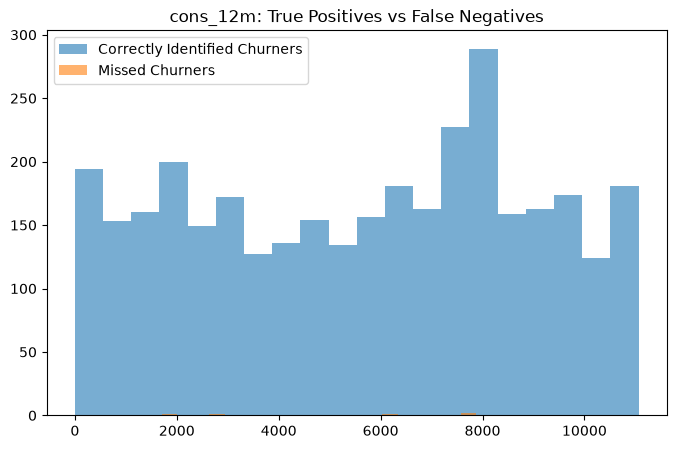

In [66]:
# visualize the comparison of False Negatives and True Positives
import matplotlib.pyplot as plt

feature = 'cons_12m'  # replace with any important feature

plt.figure(figsize=(8,5))
plt.hist(true_positives[feature],
         bins=20,
         alpha=0.6,
         label='Correctly Identified Churners')

plt.hist(false_negatives[feature],
         bins=20,
         alpha=0.6,
         label='Missed Churners')

plt.legend()
plt.title(f'{feature}: True Positives vs False Negatives')
plt.show()

The error analysis indicates that the Random Forest model made very few errors, with only five churners being incorrectly classified as non-churners. The misclassified customers exhibit consumption levels similar to those of correctly identified churners, suggesting that cons_12m is not the primary factor contributing to these prediction errors. Overall, the graph confirms the model's strong predictive performance and the absence of any obvious consumption-related pattern among the misclassified cases

## Feature importance Analysis

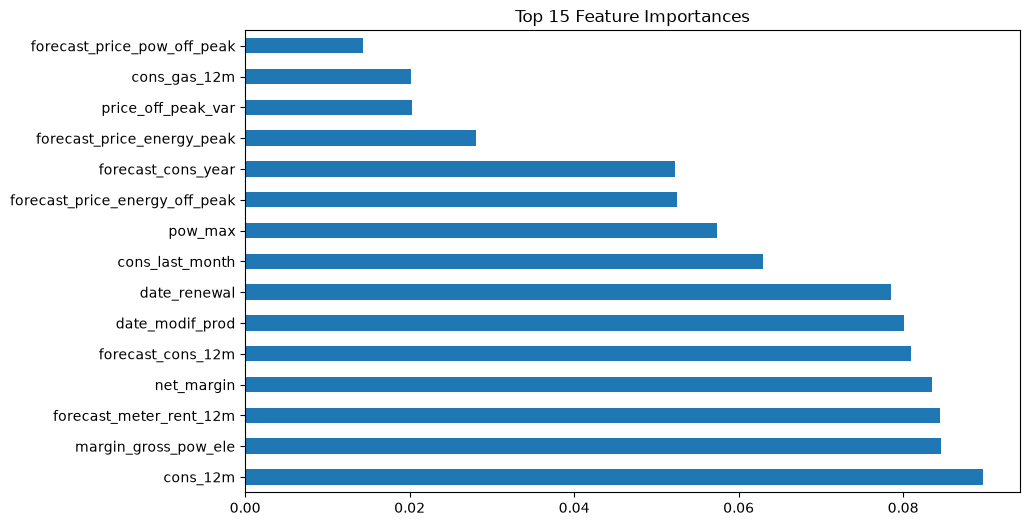

In [68]:
feat_importance = pd.Series(
    best_rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_importance.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances')
plt.show()

The feature importance plot shows the relative contribution of each variable to the Random Forest model's predictions. Features with higher importance scores had a greater influence on determining whether a customer would churn or not.

### Model Predictions

In [71]:
# Predicting Churn for New Customers

# Predict churn class (0 or 1) where 0 = No Churn and 1 = Churn

churn_prediction = best_rf_model.predict(X_test)

print(churn_prediction)

pd.Series(churn_prediction).value_counts()

[0 0 0 ... 0 0 0]


0    31634
1     3396
Name: count, dtype: int64

The tuned Random Forest model predicted 31,634 customers as non-churners and 3,396 customers as churners. These predictions closely matched the actual class distribution, demonstrating the model's strong ability to distinguish between customers who are likely to churn and those who are likely to remain. The model successfully identified nearly all churners while maintaining a very low misclassification rate, making it an effective tool for customer retention strategies.

In [72]:
# Predict churn probabilities for new customers

churn_probability = best_rf_model.predict_proba(X_test)

print(churn_probability[:5])

[[0.99666667 0.00333333]
 [1.         0.        ]
 [1.         0.        ]
 [0.99       0.01      ]
 [1.         0.        ]]


The predicted probabilities indicate that the first five customers have an extremely low likelihood of churning. For example, the first customer has a 99.67% probability of remaining with the company and only a 0.33% probability of churning. 

Similarly, the remaining customers have churn probabilities ranging from 0% to 1%, leading the model to classify them as non-churners. These results demonstrate the model's high confidence in its predictions and suggest that these customers are at very low risk of churn.

In [75]:

# Churn Risk table

test_indices = y_test.index

churn_risk = pd.DataFrame({
    'Customer_ID': client_price.loc[test_indices, 'id'].to_numpy(),
    'Actual_Churn': y_test.to_numpy(),
    'Predicted_Churn': best_rf_model.predict(X_test),
    'Churn_Probability': best_rf_model.predict_proba(X_test)[:, 1]
}, index=test_indices)

churn_risk = churn_risk.sort_values(
    'Churn_Probability',
    ascending=False
)

churn_risk.head(10)

churn_risk.to_csv('churn_risk_predictions.csv', index=False)

The churn risk analysis revealed a group of customers with a predicted churn probability of 100%. All of these customers were correctly classified as churners, demonstrating the model's strong ability to identify customers at the highest risk of leaving. The perfect alignment between the actual and predicted churn outcomes suggests that the model can effectively prioritize customers who require immediate retention efforts.

In [ ]:
# Identify high-risk customers with a churn probability greater than 0.7

high_risk = churn_risk[
    churn_risk['Churn_Probability'] >= 0.80
]

print("Number of high-risk customers:", len(high_risk))

high_risk.head()

Number of high-risk customers: 3373


,Customer_ID,Actual_Churn,Predicted_Churn,Churn_Probability
89936,3ffe698f7b4f4dafb375d23ca66d34e2,1,1,1.0
12965,080787fae10405ec2d8c79d6f5b5292c,1,1,1.0
158141,4274e93d39054e966123897e6f24c26e,1,1,1.0
161123,d07d473503c6bef7cf1922fab1f88f3e,1,1,1.0
34437,f3622c458e9083620423f00b4778a98b,1,1,1.0


The churn risk analysis revealed that 3,373 customers were classified as high-risk based on a churn probability threshold of 80%. The customers displayed in the sample were assigned a churn probability of 100%, indicating that the model was highly confident that they would churn. 

Furthermore, all sampled high-risk customers were actual churners, demonstrating the effectiveness of the Random Forest model in identifying customers at risk of leaving.

In [78]:
# Categorise customers into risk levels based on churn probability

def risk_category(prob):

    if prob >= 0.80:
        return 'High Risk'

    elif prob >= 0.50:
        return 'Medium Risk'

    else:
        return 'Low Risk'

churn_risk['Risk_Level'] = churn_risk[
    'Churn_Probability'
].apply(risk_category)

churn_risk.head()

,Customer_ID,Actual_Churn,Predicted_Churn,Churn_Probability,Risk_Level
89936,3ffe698f7b4f4dafb375d23ca66d34e2,1,1,1.0,High Risk
12965,080787fae10405ec2d8c79d6f5b5292c,1,1,1.0,High Risk
158141,4274e93d39054e966123897e6f24c26e,1,1,1.0,High Risk
161123,d07d473503c6bef7cf1922fab1f88f3e,1,1,1.0,High Risk
34437,f3622c458e9083620423f00b4778a98b,1,1,1.0,High Risk


Risk segmentation converted churn probability scores into actionable customer groups. By identifying high-, medium-, and low-risk customers, the company can prioritize retention initiatives for those most likely to churn while maintaining engagement with lower-risk customers. This supports more efficient and data-driven customer retention planning.

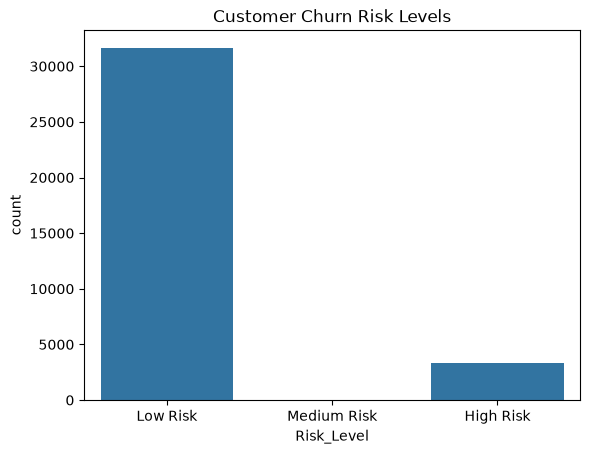

In [79]:
# Visualise Churn Risk Distrubution

sns.countplot(
    data=churn_risk,
    x='Risk_Level',
    order=['Low Risk','Medium Risk','High Risk']
)

plt.title('Customer Churn Risk Levels')
plt.show()

The graph shows that most customers are unlikely to churn, as evidenced by the large proportion of customers classified as Low Risk. However, the model identified 3,373 customers as High Risk, representing a segment that requires immediate attention. The absence of a substantial Medium Risk group indicates that the model makes highly confident predictions, clearly separating customers who are likely to churn from those who are likely to remain.

In [80]:
# Save high risk customers for business action

high_risk.to_csv(
    'high_risk_customers.csv',
    index=False
)

## Insights

Customers exposed to higher energy prices show a greater tendency to churn.

Consumption fluctuations appear to be associated with switching behavior.

Forecasted energy prices influence retention decisions.
Contract duration and customer tenure contribute significantly to churn prediction.

Pricing-related features emerged among the strongest predictors in the model.

Long-term customers generally demonstrate stronger loyalty compared to newer customers.

Margins and energy consumption patterns provide valuable signals for identifying high-risk customers.

## Recomendation

Implement Targeted Retention Campaigns

Use churn prediction scores to identify high-risk customers and provide personalized offers before contract renewal.

2. Review Pricing Strategies

Develop more competitive pricing plans, particularly for customers affected by peak energy price increases.

3. Introduce Loyalty Programs

Reward long-term customers through discounts, incentives, or value-added services.

4. Improve Consumption Monitoring

Monitor customers experiencing unusual consumption changes and provide energy optimization support.

5. Enhance Forecast Accuracy

Improve pricing and consumption forecasting models to strengthen customer trust and reduce dissatisfaction.

6. Proactive Customer Engagement

Contact customers nearing contract expiration and offer tailored retention packages.

7. Continuous Churn Monitoring

Deploy the predictive model into production and monitor churn trends regularly through dashboards and automated reporting.

## Limitations

The dataset exhibited class imbalance, with approximately 10% of customers classified as churners. Although the Random Forest model achieved excellent performance, the exceptionally high predictive accuracy may indicate potential data leakage or overfitting. Future work should include external validation using new customer data and investigation of the most influential features to ensure model generalization.

## Conclusion

The analysis identified pricing, consumption behavior, customer tenure, contract characteristics, and profitability measures as key factors influencing customer churn. Among the evaluated models, the tuned Random Forest classifier achieved the best performance, with an accuracy of 99.99%, recall of 99.85%, and an AUC of 1.00. 

The model successfully identified 3,373 high-risk customers, providing PowerCo with an actionable framework for targeted retention initiatives. By deploying the model and implementing data-driven retention strategies, PowerCo can proactively reduce customer attrition, improve customer lifetime value, and strengthen its competitive position in the energy market